# Stack Overflow Developer Survey Analysis

## Project Overview
This project analyzes the Stack Overflow Developer Survey dataset from Kaggle to explore:

- Developer demographics
- Programming language trends
- Developer experience levels
- Education background
- Employment patterns
- Technology preferences

The objective is to practice exploratory data analysis (EDA) and derive meaningful insights from real-world survey data using Python and data visualization libraries.

### Tools Used
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Plotly Express

### Dataset Source
Stack Overflow Developer Survey Dataset (kaggle)

In [1]:
# importing required libraries for data manipulatio and visualization
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

## Data Loading

In this section, we load the Stack Overflow survey dataset and perform an initial inspection to understand its structure.

In [2]:
survey_raw_df = pd.read_csv('survey_results_public.csv')
schema_raw_df = pd.read_csv('survey_results_schema.csv')

In [3]:
survey_raw_df

,Respondent,MainBranch,Hobbyist,Age,Age1stCode,CompFreq,CompTotal,ConvertedComp,Country,CurrencyDesc,...,SurveyEase,SurveyLength,Trans,UndergradMajor,WebframeDesireNextYear,WebframeWorkedWith,WelcomeChange,WorkWeekHrs,YearsCode,YearsCodePro
0,1,I am a developer by profession,Yes,NaN,13,Monthly,NaN,NaN,Germany,European Euro,...,Neither easy nor difficult,Appropriate in length,No,"Computer science, computer engineering, or sof...",ASP.NET Core,ASP.NET;ASP.NET Core,Just as welcome now as I felt last year,50.0,36,27
1,2,I am a developer by profession,No,NaN,19,NaN,NaN,NaN,United Kingdom,Pound sterling,...,NaN,NaN,NaN,"Computer science, computer engineering, or sof...",NaN,NaN,Somewhat more welcome now than last year,NaN,7,4
2,3,I code primarily as a hobby,Yes,NaN,15,NaN,NaN,NaN,Russian Federation,NaN,...,Neither easy nor difficult,Appropriate in length,NaN,NaN,NaN,NaN,Somewhat more welcome now than last year,NaN,4,NaN
3,4,I am a developer by profession,Yes,25.0,18,NaN,NaN,NaN,Albania,Albanian lek,...,NaN,NaN,No,"Computer science, computer engineering, or sof...",NaN,NaN,Somewhat less welcome now than last year,40.0,7,4
4,5,"I used to be a developer by profession, but no...",Yes,31.0,16,NaN,NaN,NaN,United States,NaN,...,Easy,Too short,No,"Computer science, computer engineering, or sof...",Django;Ruby on Rails,Ruby on Rails,Just as welcome now as I felt last year,NaN,15,8
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
64456,64858,NaN,Yes,NaN,16,NaN,NaN,NaN,United States,NaN,...,NaN,NaN,NaN,"Computer science, computer engineering, or sof...",NaN,NaN,NaN,NaN,10,Less than 1 year
64457,64867,NaN,Yes,NaN,NaN,NaN,NaN,NaN,Morocco,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
64458,64898,NaN,Yes,NaN,NaN,NaN,NaN,NaN,Viet Nam,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
64459,64925,NaN,Yes,NaN,NaN,NaN,NaN,NaN,Poland,NaN,...,NaN,NaN,NaN,NaN,Angular;Angular.js;React.js,NaN,NaN,NaN,NaN,NaN


In [4]:
schema_raw_df

,Column,QuestionText
0,Respondent,Randomized respondent ID number (not in order ...
1,MainBranch,Which of the following options best describes ...
2,Hobbyist,Do you code as a hobby?
3,Age,What is your age (in years)? If you prefer not...
4,Age1stCode,At what age did you write your first line of c...
...,...,...
56,WebframeWorkedWith,Which web frameworks have you done extensive d...
57,WelcomeChange,"Compared to last year, how welcome do you feel..."
58,WorkWeekHrs,"On average, how many hours per week do you wor..."
59,YearsCode,"Including any education, how many years have y..."


## Exploring the Dataset

Let's take a quick look at the dataset structure, summary statistics, and missing values before moving on to the analysis.


In [5]:
survey_raw_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 64461 entries, 0 to 64460
Data columns (total 61 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Respondent                    64461 non-null  int64  
 1   MainBranch                    64162 non-null  str    
 2   Hobbyist                      64416 non-null  str    
 3   Age                           45446 non-null  float64
 4   Age1stCode                    57900 non-null  str    
 5   CompFreq                      40069 non-null  str    
 6   CompTotal                     34826 non-null  float64
 7   ConvertedComp                 34756 non-null  float64
 8   Country                       64072 non-null  str    
 9   CurrencyDesc                  45472 non-null  str    
 10  CurrencySymbol                45472 non-null  str    
 11  DatabaseDesireNextYear        44070 non-null  str    
 12  DatabaseWorkedWith            49537 non-null  str    
 13  DevType     

In [6]:
survey_raw_df.describe()

C:\Users\ashwi\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\pandas\core\nanops.py:1028: RuntimeWarning: overflow encountered in square
  sqr = _ensure_numeric((avg - values) ** 2)


,Respondent,Age,CompTotal,ConvertedComp,WorkWeekHrs
count,64461.000000,45446.000000,3.482600e+04,3.475600e+04,41151.000000
mean,32554.079738,30.834111,3.190464e+242,1.037561e+05,40.782174
std,18967.442360,9.585392,inf,2.268853e+05,17.816383
min,1.000000,1.000000,0.000000e+00,0.000000e+00,1.000000
25%,16116.000000,24.000000,2.000000e+04,2.464800e+04,40.000000
50%,32231.000000,29.000000,6.300000e+04,5.404900e+04,40.000000
75%,49142.000000,35.000000,1.250000e+05,9.500000e+04,44.000000
max,65639.000000,279.000000,1.111111e+247,2.000000e+06,475.000000


In [7]:
survey_raw_df.isna().sum()

Respondent                0
MainBranch              299
Hobbyist                 45
Age                   19015
Age1stCode             6561
                      ...  
WebframeWorkedWith    22182
WelcomeChange         11778
WorkWeekHrs           23310
YearsCode              6777
YearsCodePro          18112
Length: 61, dtype: int64

### Observations

* The dataset contains 64,461 survey responses and 61 features.
* Most columns are categorical (`str` type), while a few numerical columns such as `Age`, `CompTotal`, `ConvertedComp`, and `WorkWeekHrs` are stored as numeric values.
* Several columns contain missing values. For example, `Age`, `CompTotal`, `WorkWeekHrs`, and `YearsCodePro` have a significant number of null entries.
* The average respondent age is approximately 31 years.
* WorkWeekHrs contains `475 hours per week` which is incorrect. 
* Most respondents report working around 40 hours per week.
* Data cleaning will be necessary before performing detailed analysis on some features.


## Data Preparation and Cleaning

The original dataset contains 61 columns, many of which are not relevant to the objectives of this analysis. To make the analysis more focused and manageable, we select a subset of columns related to demographics, programming experience, and employment. These features will be used for further cleaning and exploration.


In [8]:
selected_features = [
    #Demographics
    'Country',
    'Age',
    'Gender',
    'EdLevel',
    'UndergradMajor',
    #Programming experience
    'Hobbyist',
    'Age1stCode',
    'YearsCodePro',
    'LanguageWorkedWith',
    'LanguageDesireNextYear',
    'NEWLearn',
    'NEWStuck',
    #Employment
    'Employment',
    'DevType',
    'WorkWeekHrs',
    'JobSat',
    'JobFactors',
    'NEWOvertime',
]

### Selected Features

The selected columns provide information about:

* Developer demographics (country, age, gender, education)
* Programming experience and learning habits
* Programming language preferences
* Employment status and job satisfaction

Focusing on these features helps us explore developer backgrounds, skills, and career-related trends more effectively.


### Creating a Working Copy
Here we created a copy of dataset so that any cleaning and transformation steps do not affect the original data.


In [9]:
print(f'length of selected features is: {len(selected_features)}')

length of selected features is: 18


In [10]:
survey_df = survey_raw_df[selected_features].copy()
schema_df = schema_raw_df.set_index('Column')
schema_df = schema_df.loc[selected_features]

In [11]:
schema_df.loc['Hobbyist']

QuestionText    Do you code as a hobby?
Name: Hobbyist, dtype: str

In [12]:
schema_raw_df

,Column,QuestionText
0,Respondent,Randomized respondent ID number (not in order ...
1,MainBranch,Which of the following options best describes ...
2,Hobbyist,Do you code as a hobby?
3,Age,What is your age (in years)? If you prefer not...
4,Age1stCode,At what age did you write your first line of c...
...,...,...
56,WebframeWorkedWith,Which web frameworks have you done extensive d...
57,WelcomeChange,"Compared to last year, how welcome do you feel..."
58,WorkWeekHrs,"On average, how many hours per week do you wor..."
59,YearsCode,"Including any education, how many years have y..."


### Inspecting the Prepared Dataset

After selecting the relevant columns, let's take a quick look at the shape and structure of the new DataFrame. This helps verify that the required features have been successfully extracted and are ready for further cleaning and analysis.


In [13]:
print(survey_df.shape)

print()
survey_df.info()

(64461, 18)

<class 'pandas.DataFrame'>
RangeIndex: 64461 entries, 0 to 64460
Data columns (total 18 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Country                 64072 non-null  str    
 1   Age                     45446 non-null  float64
 2   Gender                  50557 non-null  str    
 3   EdLevel                 57431 non-null  str    
 4   UndergradMajor          50995 non-null  str    
 5   Hobbyist                64416 non-null  str    
 6   Age1stCode              57900 non-null  str    
 7   YearsCodePro            46349 non-null  str    
 8   LanguageWorkedWith      57378 non-null  str    
 9   LanguageDesireNextYear  54113 non-null  str    
 10  NEWLearn                56156 non-null  str    
 11  NEWStuck                54983 non-null  str    
 12  Employment              63854 non-null  str    
 13  DevType                 49370 non-null  str    
 14  WorkWeekHrs             41151 non-nu

In [14]:
survey_df.describe()

,Age,WorkWeekHrs
count,45446.000000,41151.000000
mean,30.834111,40.782174
std,9.585392,17.816383
min,1.000000,1.000000
25%,24.000000,40.000000
50%,29.000000,40.000000
75%,35.000000,44.000000
max,279.000000,475.000000


- Here we can quickly observe that there are 2 columns with float type columns and 16 columns with string type.

- Many of the columns containig null values.

- Some columns must be float type like Age1stCode, YearsCodePro.

- Here seems to be problem with `Age` and `WorkWeekHrs` columns as min age is `1`, max is `279` and `max WorkWeekHrs` is `475`. these values are incorrect and misentered while collecting data.

### Handling Values

Before starting the analysis, we examine the missing values in the selected features. Depending on the importance of a column and the amount of missing data, we may either remove missing entries or keep them for later analysis.


In [15]:
survey_df.Age1stCode.unique()

<ArrowStringArray>
[                  '13',                   '19',                   '15',
                   '18',                   '16',                   '14',
                   '12',                   '20',                   '42',
                    '8',                   '25',                   '22',
                   '30',                   '17',                   '21',
                   '10',                   '46',                    '9',
                    '7',                   '11',                    '6',
                    nan,                   '31',                   '29',
                    '5', 'Younger than 5 years',                   '28',
                   '38',                   '23',                   '27',
                   '41',                   '24',                   '53',
                   '26',                   '35',                   '32',
                   '40',                   '33',                   '36',
                   '54',        

In [16]:
survey_df.YearsCodePro.unique()

<ArrowStringArray>
[                '27',                  '4',                  nan,
                  '8',                 '13',                  '2',
                  '7',                 '20',                  '1',
                 '23',                  '3',                 '12',
                 '17',                 '18',                 '10',
                 '14',                 '29',                  '6',
                 '28',                  '9',                 '15',
                 '11',                 '16',                 '25',
   'Less than 1 year',                  '5',                 '21',
                 '19',                 '35',                 '24',
                 '32',                 '22',                 '30',
                 '38',                 '26',                 '40',
                 '33',                 '31', 'More than 50 years',
                 '34',                 '36',                 '39',
                 '37',                 '41'

We can observes columns like `Age1stCode`, `YearsCodePro` are `str` type but it must be numeric type, so in order to make our analysis easier we'll make these columns using `.to_numeric`.

- `errors = coerce` covert...
-  valid numeric string like ("42","2.0") to numbers.
-  Invalid string like ("abc", "unknown") to NaN (not number).

In [17]:
survey_df['Age1stCode'] = pd.to_numeric(survey_df['Age1stCode'], errors = 'coerce')
survey_df['YearsCodePro'] = pd.to_numeric(survey_df['YearsCodePro'], errors = 'coerce')

Here I drop the columns where age is higher than 80 years and less than 10 years.
I 'll also drop where `WorkWeekHrs` is more than 119 hours( if 1 day = 19hrs, then 7 day = 7*19 = 119hrs).

In [18]:
survey_df.drop(survey_df[survey_df['Age'] < 10].index, inplace = True)
survey_df.drop(survey_df[survey_df['Age'] > 91].index, inplace = True)
survey_df.drop(survey_df[survey_df['WorkWeekHrs'] > 119].index, inplace = True)

In [19]:
survey_df.describe()

,Age,Age1stCode,YearsCodePro,WorkWeekHrs
count,45285.000000,57290.000000,43963.000000,40970.000000
mean,30.809628,15.475999,8.873485,39.970399
std,9.426202,5.115779,7.762187,10.401071
min,10.000000,5.000000,1.000000,1.000000
25%,24.000000,12.000000,3.000000,40.000000
50%,29.000000,15.000000,6.000000,40.000000
75%,35.000000,18.000000,12.000000,43.000000
max,89.000000,85.000000,50.000000,115.000000


In [20]:
survey_df.info()

<class 'pandas.DataFrame'>
Index: 64266 entries, 0 to 64460
Data columns (total 18 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Country                 63877 non-null  str    
 1   Age                     45285 non-null  float64
 2   Gender                  50395 non-null  str    
 3   EdLevel                 57245 non-null  str    
 4   UndergradMajor          50838 non-null  str    
 5   Hobbyist                64221 non-null  str    
 6   Age1stCode              57290 non-null  float64
 7   YearsCodePro            43963 non-null  float64
 8   LanguageWorkedWith      57203 non-null  str    
 9   LanguageDesireNextYear  53948 non-null  str    
 10  NEWLearn                55987 non-null  str    
 11  NEWStuck                54805 non-null  str    
 12  Employment              63660 non-null  str    
 13  DevType                 49191 non-null  str    
 14  WorkWeekHrs             40970 non-null  float64
 15  J

## Gender Analysis

Let's take a look at the different gender categories and their distribution in the dataset.


In [21]:
survey_df['Gender'].unique()

<ArrowStringArray>
[                                                        'Man',
                                                           nan,
                                                       'Woman',
       'Man;Non-binary, genderqueer, or gender non-conforming',
           'Non-binary, genderqueer, or gender non-conforming',
     'Woman;Non-binary, genderqueer, or gender non-conforming',
                                                   'Woman;Man',
 'Woman;Man;Non-binary, genderqueer, or gender non-conforming']
Length: 8, dtype: str

In [22]:
survey_df['Gender'].value_counts()

Gender
Man                                                            45871
Woman                                                           3833
Non-binary, genderqueer, or gender non-conforming                382
Man;Non-binary, genderqueer, or gender non-conforming            121
Woman;Non-binary, genderqueer, or gender non-conforming           92
Woman;Man                                                         73
Woman;Man;Non-binary, genderqueer, or gender non-conforming       23
Name: count, dtype: int64

In [23]:
survey_df.where(~(survey_df.Gender.str.contains(';', na = False)), np.nan, inplace = True)

,Country,Age,Gender,EdLevel,UndergradMajor,Hobbyist,Age1stCode,YearsCodePro,LanguageWorkedWith,LanguageDesireNextYear,NEWLearn,NEWStuck,Employment,DevType,WorkWeekHrs,JobSat,JobFactors,NEWOvertime
0,Germany,NaN,Man,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)","Computer science, computer engineering, or sof...",Yes,13.0,27.0,C#;HTML/CSS;JavaScript,C#;HTML/CSS;JavaScript,Once a year,Visit Stack Overflow;Go for a walk or other ph...,"Independent contractor, freelancer, or self-em...","Developer, desktop or enterprise applications;...",50.0,Slightly satisfied,"Languages, frameworks, and other technologies ...",Often: 1-2 days per week or more
1,United Kingdom,NaN,NaN,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)","Computer science, computer engineering, or sof...",No,19.0,4.0,JavaScript;Swift,Python;Swift,Once a year,Visit Stack Overflow;Go for a walk or other ph...,Employed full-time,"Developer, full-stack;Developer, mobile",NaN,Very dissatisfied,NaN,NaN
2,Russian Federation,NaN,NaN,NaN,NaN,Yes,15.0,NaN,Objective-C;Python;Swift,Objective-C;Python;Swift,Once a decade,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Albania,25.0,Man,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)","Computer science, computer engineering, or sof...",Yes,18.0,4.0,NaN,NaN,Once a year,NaN,NaN,NaN,40.0,Slightly dissatisfied,Flex time or a flexible schedule;Office enviro...,Occasionally: 1-2 days per quarter but less th...
4,United States,31.0,Man,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)","Computer science, computer engineering, or sof...",Yes,16.0,8.0,HTML/CSS;Ruby;SQL,Java;Ruby;Scala,Once a year,Call a coworker or friend;Visit Stack Overflow...,Employed full-time,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
64456,United States,NaN,NaN,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)","Computer science, computer engineering, or sof...",Yes,16.0,NaN,NaN,NaN,Once a decade,Call a coworker or friend,Employed full-time,Senior executive/VP,NaN,NaN,NaN,NaN
64457,Morocco,NaN,NaN,NaN,NaN,Yes,NaN,NaN,Assembly;Bash/Shell/PowerShell;C;C#;C++;Dart;G...,Assembly;Bash/Shell/PowerShell;C;C#;C++;Dart;G...,NaN,NaN,Employed full-time,NaN,NaN,NaN,NaN,NaN
64458,Viet Nam,NaN,NaN,Primary/elementary school,NaN,Yes,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
64459,Poland,NaN,NaN,NaN,NaN,Yes,NaN,NaN,HTML/CSS,HTML/CSS;Java;JavaScript,Once a year,Call a coworker or friend;Visit Stack Overflow,Employed full-time,NaN,NaN,NaN,NaN,NaN


Now we have cleaned up and prepared the dataset for analysis. Let's take a look at sample rows from the dataframe.

In [24]:
survey_df.sample(10)

,Country,Age,Gender,EdLevel,UndergradMajor,Hobbyist,Age1stCode,YearsCodePro,LanguageWorkedWith,LanguageDesireNextYear,NEWLearn,NEWStuck,Employment,DevType,WorkWeekHrs,JobSat,JobFactors,NEWOvertime
47915,France,30.0,Man,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)","Computer science, computer engineering, or sof...",Yes,16.0,10.0,Bash/Shell/PowerShell;HTML/CSS;JavaScript;SQL;...,Bash/Shell/PowerShell;HTML/CSS;JavaScript;Type...,Once a year,Play games;Call a coworker or friend;Visit Sta...,Employed full-time,"Developer, front-end",40.0,Slightly satisfied,"Industry that I’d be working in;Languages, fra...",Occasionally: 1-2 days per quarter but less th...
38104,India,NaN,NaN,NaN,NaN,No,NaN,NaN,C;C#;C++;HTML/CSS;Java;JavaScript;SQL;TypeScript,Python,Every few months,NaN,Employed full-time,NaN,NaN,NaN,NaN,NaN
21721,United States,42.0,Man,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)","Computer science, computer engineering, or sof...",Yes,15.0,26.0,HTML/CSS;JavaScript;PHP;SQL,HTML/CSS;JavaScript;SQL,Every few months,Visit Stack Overflow;Go for a walk or other ph...,Employed full-time,"Developer, back-end;Developer, front-end;Devel...",55.0,Very satisfied,Flex time or a flexible schedule;Remote work o...,Often: 1-2 days per week or more
44094,India,29.0,Man,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)","Computer science, computer engineering, or sof...",Yes,21.0,4.0,Java;JavaScript,Kotlin;Python;R;Ruby;Rust;Scala,Every few months,Call a coworker or friend;Visit Stack Overflow...,Employed full-time,"Developer, full-stack",40.0,Slightly satisfied,"Languages, frameworks, and other technologies ...",Occasionally: 1-2 days per quarter but less th...
62188,South Korea,NaN,NaN,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)","Computer science, computer engineering, or sof...",No,15.0,10.0,NaN,NaN,NaN,NaN,Employed full-time,NaN,NaN,NaN,NaN,NaN
36105,United States,NaN,NaN,NaN,NaN,Yes,NaN,NaN,Bash/Shell/PowerShell;C;C#;C++;HTML/CSS;Java;J...,R;Rust,Every few months,Meditate;Call a coworker or friend;Visit Stack...,Student,NaN,NaN,NaN,NaN,NaN
24265,United Kingdom,48.0,Woman,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)","A humanities discipline (such as literature, h...",No,8.0,25.0,C#;HTML/CSS;JavaScript;SQL;TypeScript,C#;HTML/CSS;JavaScript;SQL;TypeScript,Once a year,Call a coworker or friend;Visit Stack Overflow...,Employed full-time,NaN,40.0,Very dissatisfied,Flex time or a flexible schedule;Remote work o...,Sometimes: 1-2 days per month but less than we...
36709,South Korea,NaN,NaN,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)","Computer science, computer engineering, or sof...",Yes,15.0,2.0,C;C#;C++;Go;Java;JavaScript;Python,Go;Python;Rust,Once a year,Play games,Employed part-time,"Developer, full-stack",NaN,Slightly satisfied,NaN,NaN
49698,India,NaN,NaN,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)","Computer science, computer engineering, or sof...",No,24.0,12.0,C;HTML/CSS;Java;JavaScript;Kotlin;Objective-C;...,Assembly;Perl;Ruby;TypeScript,Every few months,NaN,Employed full-time,"Database administrator;Developer, back-end;Dev...",55.0,Very dissatisfied,Diversity of the company or organization;Speci...,Often: 1-2 days per week or more
21601,Germany,27.0,Man,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)","Computer science, computer engineering, or sof...",Yes,12.0,2.0,Bash/Shell/PowerShell;HTML/CSS;Java;JavaScript...,Java;Kotlin,Every few months,Call a coworker or friend;Visit Stack Overflow...,Employed full-time,"Developer, back-end;Developer, full-stack;Educ...",40.0,Very satisfied,"Flex time or a flexible schedule;Languages, fr...",Never


# Visualization
- Here we are going to visualize the data with various features and the respondents according to various features.
- Further we will move to see the relationship bw various features and how they related to each other in order to contribute.

## Respondents by Country
This chart highlights the countries with the highest number of survey participants.

In [25]:
schema_df.loc['Country']

QuestionText    Where do you live?
Name: Country, dtype: str

In [26]:
survey_df.Country.unique()

<ArrowStringArray>
[                           'Germany',                     'United Kingdom',
                 'Russian Federation',                            'Albania',
                      'United States',                              'India',
                            'Tunisia',                              'Spain',
                        'Netherlands',                             'France',
 ...
 'Micronesia, Federated States of...',                             'Gambia',
                        'North Korea',                      'Liechtenstein',
                             'Monaco',                        'Timor-Leste',
                    'Solomon Islands',                         'Cape Verde',
                              'Gabon',                   'Marshall Islands']
Length: 184, dtype: str

In [27]:
# There are 184 unique countries. Let's plot for top10 highest countries respondents.
top10_countries = survey_df.Country.value_counts().head(10).reset_index()
top10_countries

,Country,count
0,United States,12368
1,India,8355
2,United Kingdom,3880
3,Germany,3864
4,Canada,2174
5,France,1884
6,Brazil,1804
7,Netherlands,1332
8,Poland,1259
9,Australia,1199


In [28]:
top10_countries.columns = ['Country','Respondents']

top10_countries

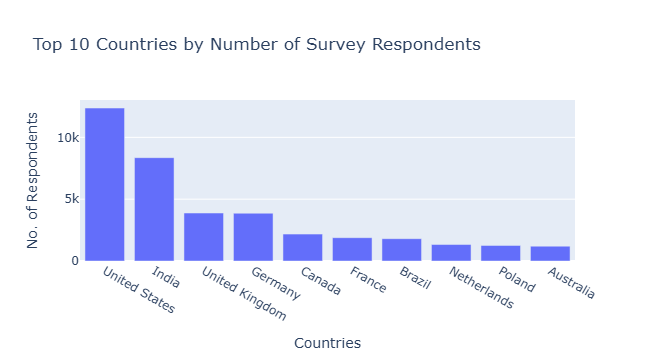

In [66]:
fig = px.bar(top10_countries,
            x = 'Country',
            y = 'Respondents',
            title = 'Top 10 Countries by Number of Survey Respondents')
fig.update_layout(xaxis_title = 'Countries',
                 yaxis_title = 'No. of Respondents')
fig.show()

### Observation

- The United States contributed the highest number of survey responses.
- India ranked second and had strong representation in the survey.
- Participation was concentrated in a few countries, with a noticeable drop after the top four countries.
- The survey reflects a broad international developer community.

## Gender Distribution

This chart shows the distribution of survey respondents by gender. Understanding the demographic composition of the dataset helps provide context for later analyses.

In [67]:
gender_counts = survey_df.Gender.value_counts().reset_index()
gender_counts

,Gender,count
0,Man,45871
1,Woman,3833
2,"Non-binary, genderqueer, or gender non-conforming",382


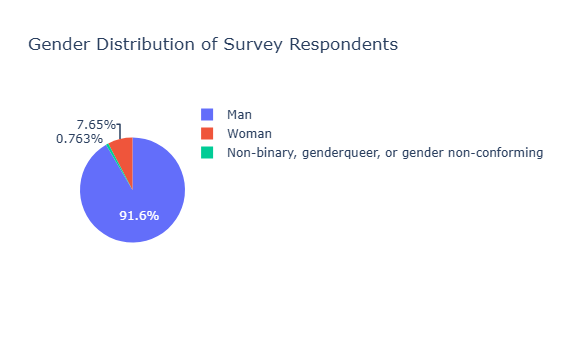

In [68]:
fig = px.pie(gender_counts,
            names = 'Gender',
            values = 'count',
            title = 'Gender Distribution of Survey Respondents')
fig.show()

### Observation

- The majority of respondents identified as men.
- Women and other gender groups accounted for a smaller share of survey participants.
- The survey population is not evenly distributed across gender categories.

## Age Distribution

This visualization explores the age distribution of developers who participated in the survey.

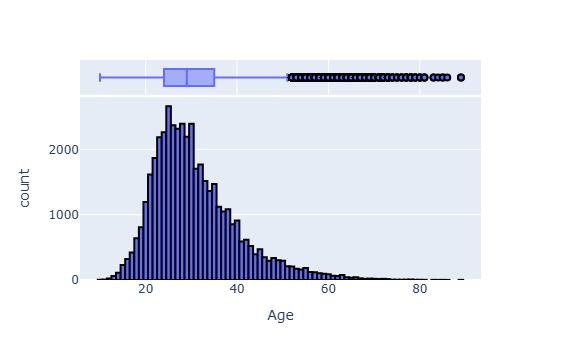

In [69]:
fig = px.histogram(survey_df,
                  x = 'Age',
                  marginal = 'box')
fig.update_traces(marker_line_width = 2,marker_line_color = 'black')
fig.show()

### Observation

- Most respondents fall within the young to middle-age range.
- The distribution is concentrated around the early and mid-career age groups.
- Very few respondents belong to the extreme age ranges.

## Developer Roles

This visualization shows the most common developer roles reported by respondents.

In [70]:
top10_devtype = survey_df.DevType.value_counts().head(10).reset_index()
top10_devtype

,DevType,count
0,"Developer, full-stack",4394
1,"Developer, back-end",3052
2,"Developer, back-end;Developer, front-end;Devel...",2214
3,"Developer, back-end;Developer, full-stack",1464
4,"Developer, front-end",1390
5,"Developer, mobile",1247
6,"Developer, front-end;Developer, full-stack",822
7,"Developer, back-end;Developer, desktop or ente...",809
8,"Developer, back-end;Developer, desktop or ente...",646
9,"Developer, desktop or enterprise applications",602


In [71]:
top10_devtype.columns = ['DevType','Respondents']

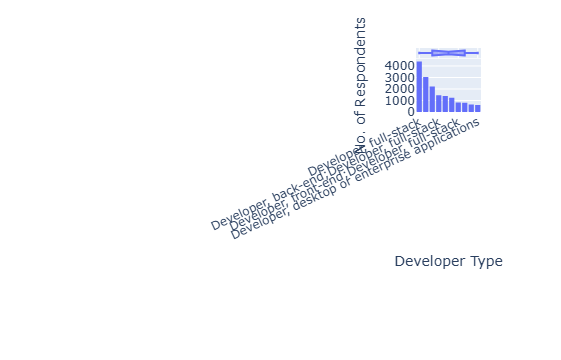

In [72]:
fig = px.histogram(top10_devtype,
                  x = 'DevType',
                  y = 'Respondents',
                  marginal = 'box')
fig.update_layout(xaxis_tickangle = -25,
                 xaxis_title = 'Developer Type',
                 yaxis_title = 'No. of Respondents')
fig.show()

### Observation

- Full-stack, back-end, and front-end development are among the most common roles.
- Many respondents work in multiple development areas.
- The survey includes a diverse range of technical professions.

## Professional Coding Experience

This chart explores the distribution of professional coding experience among respondents.

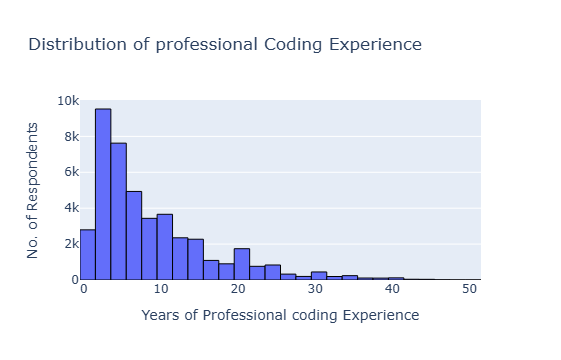

In [73]:
fig = px.histogram(survey_df,
                  x = 'YearsCodePro',
                   nbins = 30,
                  title = 'Distribution of professional Coding Experience')
fig.update_traces(marker_line_width = 1,marker_line_color = 'black')
fig.update_layout(xaxis_title = 'Years of Professional coding Experience', 
                  yaxis_title = 'No. of Respondents')
fig.show()